In [ ]:
from executor import Executor, QuantumCircuit, QuantumOperator, Parameters
from qollage import draw_circuit


In [ ]:
x = Parameters("x", 1)
p = Parameters("p", 2)

qc = QuantumCircuit(2)
qc.h(0)
qc.ryy(0, 1, p[0] * x[0])


In [ ]:
p_obs = Parameters("p_obs", 2)
observable = QuantumOperator(["ZI", "IZ"], [p_obs[0], p_obs[1]])


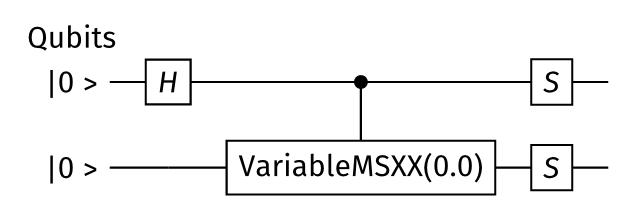

In [ ]:
executor = Executor.create("qoqo", seed=0, shots=10000)

qoqo_circuit = executor.transpile_circuit(qc)
qoqo_circuit_copy = executor.transpile_circuit(qc)
qoqo_circuit_copy.assign_parameters({"x[0]": 0.1, "p[0]": 0.3})
draw_circuit(qoqo_circuit_copy.get_qoqo_circuit())


In [ ]:
result = executor.expectation_value(
    qoqo_circuit,
    observable,
    x=[0.1],
    p=[0.3],
    p_obs=[0.5, 0.6],
)
print("Expectation value:", result)


Expectation value: 0.49664


In [ ]:
v = executor.expectation_value_derivatives(
    qoqo_circuit,
    observable,
    "x",
    "p",
    "p_obs",
    x=[0.1],
    p=[0.3],
    p_obs=[0.5, 0.6],
)
print(v)


TypeError: QoqoExecutor._expectation_value_derivatives() got an unexpected keyword argument 'x'

In [ ]:
executor.statevector(
    qoqo_circuit,
    x=[0.8],
    p=[0.5],
)


[(0.7070272331652061+0j),
 0.7070272331652061j,
 (0.01060620397470843+0j),
 0.01060620397470843j]

In [ ]:
executor.sample(
    qoqo_circuit,
    x=[0.8],
    p=[0.5],
)


{np.str_('01'): 5009, np.str_('00'): 4988, np.str_('11'): 2, np.str_('10'): 1}